# Task 4: Data Cleaning and Insight Generation from Survey Data

**Elevvo Pathways — Data Analytics Internship, Task 4 (Level 2)**

**Goal:** work with real-world survey data containing missing values, duplicates, and
inconsistent formatting; clean it and apply label encoding/mapping for categorical
variables; extract meaningful insights about respondent behavior and preferences.

**Dataset:** [2021 Kaggle Machine Learning & Data Science Survey](https://www.kaggle.com/c/kaggle-survey-2021)
— 25,973 real responses to a 42-question industry survey, sourced from a public GitHub
mirror of the original Kaggle competition data.

**Tools:** Python, pandas, seaborn, matplotlib


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110
%matplotlib inline

raw = pd.read_csv('survey2021.csv', low_memory=False)
print("Raw shape (incl. question-text row):", raw.shape)
raw.head(2)


Raw shape (incl. question-text row): (25974, 369)


,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,Q7_Part_3,...,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_8,Q38_B_Part_9,Q38_B_Part_10,Q38_B_Part_11,Q38_B_OTHER
0,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,In which country do you currently reside?,What is the highest level of formal education ...,Select the title most similar to your current ...,For how many years have you been writing code ...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,...,"In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor..."
1,910,50-54,Man,India,Bachelor’s degree,Other,5-10 years,Python,R,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Structure & Initial Cleaning

Row 0 of the raw CSV holds the full question text for every column (not a response) —
this has to be dropped before any analysis, or it gets treated as a 25,974th respondent.


In [2]:
df = raw.iloc[1:].reset_index(drop=True)
print("Respondent rows:", df.shape)


Respondent rows: (25973, 369)


## 2. Selecting the Core Questions

The raw file has 369 columns because multi-select questions are split into one column
per option (one-hot style). For a focused, readable analysis, this notebook keeps:
- 11 core single-response questions (demographics, role, experience, compensation)
- The full "Programming languages used regularly" question (Q7), which is multi-select


In [3]:
core_cols = ['Time from Start to Finish (seconds)','Q1','Q2','Q3','Q4','Q5','Q6',
             'Q8','Q15','Q20','Q21','Q25']
lang_cols = [c for c in df.columns if c.startswith('Q7_Part') or c == 'Q7_OTHER']

sub = df[core_cols + lang_cols].copy()
sub.columns = ['Duration_sec','Age','Gender','Country','Education','Role',
               'CodingExperience','RecommendedLanguage','MLExperience',
               'Industry','CompanySize','Compensation'] + \
              ['Lang_' + c.split('_')[-1] if c != 'Q7_OTHER' else 'Lang_Other' for c in lang_cols]

lang_names = {'Lang_1':'Python','Lang_2':'R','Lang_3':'SQL','Lang_4':'C','Lang_5':'C++',
              'Lang_6':'Java','Lang_7':'Javascript','Lang_8':'Julia','Lang_9':'Swift',
              'Lang_10':'Bash','Lang_11':'MATLAB','Lang_12':'None','Lang_Other':'Other'}
sub = sub.rename(columns=lang_names)

print("Working shape:", sub.shape)
sub.isna().sum()


Working shape: (25973, 25)


Duration_sec               0
Age                        0
Gender                     0
Country                    0
Education                  0
Role                       0
CodingExperience           0
RecommendedLanguage     1144
MLExperience            2219
Industry                9648
CompanySize             9722
Compensation           10582
Python                  4113
R                      20639
SQL                    15217
C                      21264
C++                    20438
Java                   21204
Javascript             21641
Julia                  25668
Swift                  25731
Bash                   23757
MATLAB                 23038
None                   25973
Other                  23398
dtype: int64

## 3. Data Cleaning

Four real data-quality issues show up in this dataset:

1. **Duplicates** — checked across the *full* 369-column response, not just a handful
   of demographic fields. Deduping on only a few shared fields (age/country/role) would
   falsely flag many different people who simply happen to share the same bucket — the
   correct check uses the complete response fingerprint.
2. **Inconsistent formatting** — the Compensation field mixes `"$0-999"` /
   `">$1,000,000"` (with a `$` sign) with `"25,000-29,999"` (without one).
3. **Missing values** — Industry, CompanySize, and Compensation are blank for
   37-41% of respondents (mostly students / unemployed who reasonably skip employment
   questions), so they're filled with an explicit `"Not Specified"` category rather
   than dropped, which would throw away over a third of the dataset.
4. **Outlier durations** — a handful of respondents have survey durations of hours to
   days, almost certainly from leaving the tab open rather than actually taking that
   long to answer.


### 3.1 Duplicate check

In [4]:
print("Exact duplicate rows (all 369 raw columns):", df.duplicated().sum())


Exact duplicate rows (all 369 raw columns): 0


### 3.2 Standardize inconsistent Compensation formatting

In [5]:
print("Before:", sorted(sub['Compensation'].dropna().unique())[:5], "...")
sub['Compensation'] = sub['Compensation'].str.replace('$', '', regex=False).str.strip()
print("After: ", sorted(sub['Compensation'].dropna().unique())[:5], "...")


Before: ['$0-999', '$500,000-999,999', '1,000-1,999', '10,000-14,999', '100,000-124,999'] ...
After:  ['0-999', '1,000-1,999', '10,000-14,999', '100,000-124,999', '125,000-149,999'] ...


### 3.3 Handle missing values

In [6]:
for col in ['Industry', 'CompanySize', 'Compensation', 'MLExperience', 'RecommendedLanguage']:
    sub[col] = sub[col].fillna('Not Specified')

# language flag columns: NaN means "not selected" -> convert to a clean 0/1 flag
lang_list = ['Python','R','SQL','C','C++','Java','Javascript','Julia','Swift','Bash','MATLAB','Other']
for lang in lang_list:
    sub[lang] = sub[lang].notna().astype(int)
sub = sub.drop(columns=['None'])  # entirely empty -- 0 respondents selected "no language"

print("Remaining nulls:", sub.isna().sum().sum())


Remaining nulls: 0


### 3.4 Flag outlier survey durations

In [7]:
sub['Duration_sec'] = sub['Duration_sec'].astype(int)
sub['Duration_Flag'] = np.select(
    [sub['Duration_sec'] < 60, sub['Duration_sec'] > 10800],
    ['Too Fast (<1 min)', 'Left Idle (>3 hrs)'],
    default='Normal'
)
sub['Duration_Flag'].value_counts()


Duration_Flag
Normal                24926
Left Idle (>3 hrs)     1047
Name: count, dtype: int64

## 4. Label Encoding / Mapping (ordinal categoricals)

Five fields are naturally *ordered* categories (e.g. more experience, higher pay), so
each is mapped to an integer code that preserves that order — this is what makes it
possible to compute things like "median compensation by experience level" in the next
section.


In [8]:
education_order = {
    'I prefer not to answer': None,
    'No formal education past high school': 0,
    'Some college/university study without earning a bachelor\u2019s degree': 1,
    'Bachelor\u2019s degree': 2,
    'Master\u2019s degree': 3,
    'Professional doctorate': 4,
    'Doctoral degree': 4,
}
coding_exp_order = {
    'I have never written code': 0, '< 1 years': 1, '1-3 years': 2,
    '3-5 years': 3, '5-10 years': 4, '10-20 years': 5, '20+ years': 6,
}
ml_exp_order = {
    'Not Specified': None, 'I do not use machine learning methods': 0,
    'Under 1 year': 1, '1-2 years': 2, '2-3 years': 3, '3-4 years': 4,
    '4-5 years': 5, '5-10 years': 6, '10-20 years': 7, '20 or more years': 8,
}
company_size_order = {
    'Not Specified': None, '0-49 employees': 0, '50-249 employees': 1,
    '250-999 employees': 2, '1000-9,999 employees': 3, '10,000 or more employees': 4,
}
comp_bins_ordered = ['0-999','1,000-1,999','2,000-2,999','3,000-3,999','4,000-4,999',
    '5,000-7,499','7,500-9,999','10,000-14,999','15,000-19,999','20,000-24,999',
    '25,000-29,999','30,000-39,999','40,000-49,999','50,000-59,999','60,000-69,999',
    '70,000-79,999','80,000-89,999','90,000-99,999','100,000-124,999','125,000-149,999',
    '150,000-199,999','200,000-249,999','250,000-299,999','300,000-499,999',
    '500,000-999,999','>1,000,000']
compensation_order = {v: i for i, v in enumerate(comp_bins_ordered)}
compensation_order['Not Specified'] = None

sub['Education_Code'] = sub['Education'].map(education_order)
sub['CodingExperience_Code'] = sub['CodingExperience'].map(coding_exp_order)
sub['MLExperience_Code'] = sub['MLExperience'].map(ml_exp_order)
sub['CompanySize_Code'] = sub['CompanySize'].map(company_size_order)
sub['Compensation_Code'] = sub['Compensation'].map(compensation_order)

sub.to_csv('survey_clean.csv', index=False)
sub[['Education','Education_Code','CodingExperience','CodingExperience_Code']].head()


,Education,Education_Code,CodingExperience,CodingExperience_Code
0,Bachelor’s degree,2.0,5-10 years,4
1,Master’s degree,3.0,20+ years,6
2,Master’s degree,3.0,1-3 years,2
3,Doctoral degree,4.0,20+ years,6
4,Doctoral degree,4.0,< 1 years,1


## 5. Insights

### Top 10 countries by respondent count

In [9]:
sub['Country'].value_counts().head(10)


Country
India                                                   7434
United States of America                                2650
Other                                                   1270
Japan                                                    921
China                                                    814
Brazil                                                   751
Russia                                                   742
Nigeria                                                  702
United Kingdom of Great Britain and Northern Ireland     550
Pakistan                                                 530
Name: count, dtype: int64

### Gender breakdown

In [10]:
(sub['Gender'].value_counts(normalize=True) * 100).round(1)


Gender
Man                        79.3
Woman                      18.8
Prefer not to say           1.4
Nonbinary                   0.3
Prefer to self-describe     0.2
Name: proportion, dtype: float64

### Most recommended first language for an aspiring data scientist

In [11]:
sub['RecommendedLanguage'].value_counts().head(6)


RecommendedLanguage
Python           20213
R                 1445
SQL               1338
Not Specified     1144
C                  440
C++                437
Name: count, dtype: int64

### Most common roles

In [12]:
sub['Role'].value_counts().head(8)


Role
Student                      6804
Data Scientist               3616
Software Engineer            2449
Other                        2393
Data Analyst                 2301
Currently not employed       1986
Research Scientist           1538
Machine Learning Engineer    1499
Name: count, dtype: int64

## 6. Visualizations

### Top 10 countries

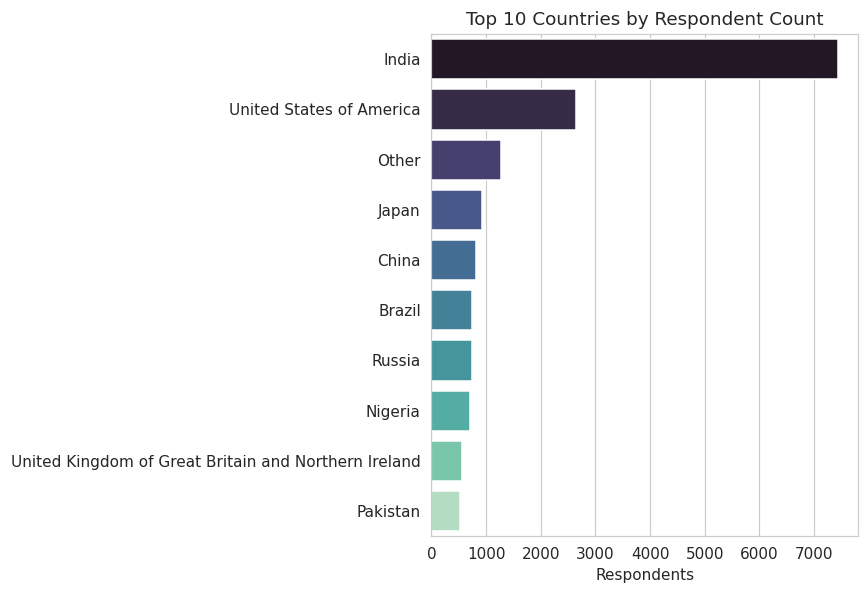

In [13]:
plt.figure(figsize=(8,5.5))
top_countries = sub['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='mako', legend=False)
plt.title('Top 10 Countries by Respondent Count')
plt.xlabel('Respondents'); plt.ylabel('')
plt.tight_layout(); plt.show()


### Programming language usage

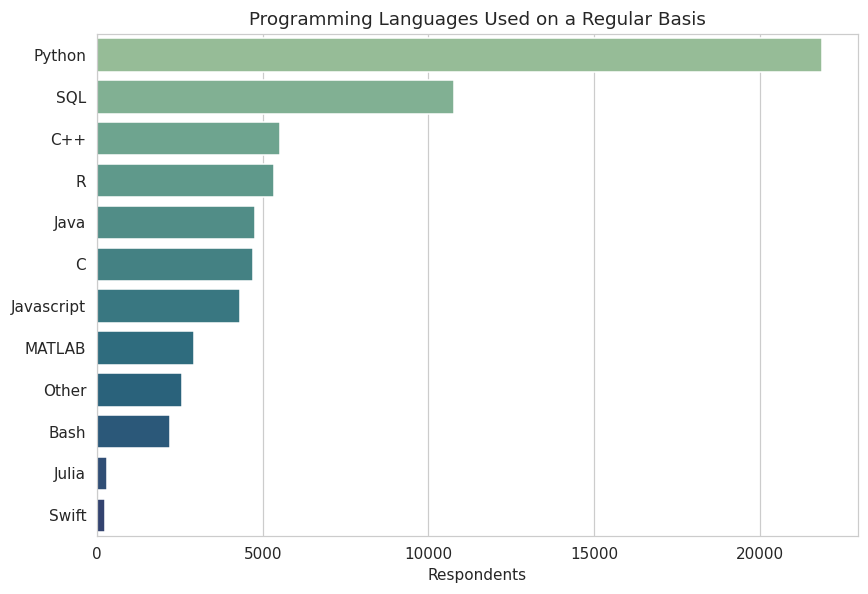

In [14]:
plt.figure(figsize=(8,5.5))
lang_counts = sub[lang_list].sum().sort_values(ascending=False)
sns.barplot(x=lang_counts.values, y=lang_counts.index, hue=lang_counts.index, palette='crest', legend=False)
plt.title('Programming Languages Used on a Regular Basis')
plt.xlabel('Respondents'); plt.ylabel('')
plt.tight_layout(); plt.show()


### Gender breakdown

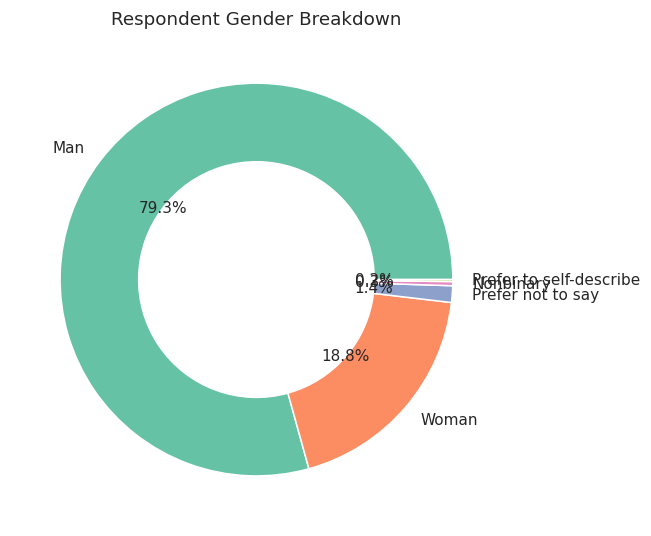

In [15]:
plt.figure(figsize=(6,6))
gender_counts = sub['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2', len(gender_counts)), wedgeprops={'width':0.4})
plt.title('Respondent Gender Breakdown')
plt.tight_layout(); plt.show()


### Respondent count by role

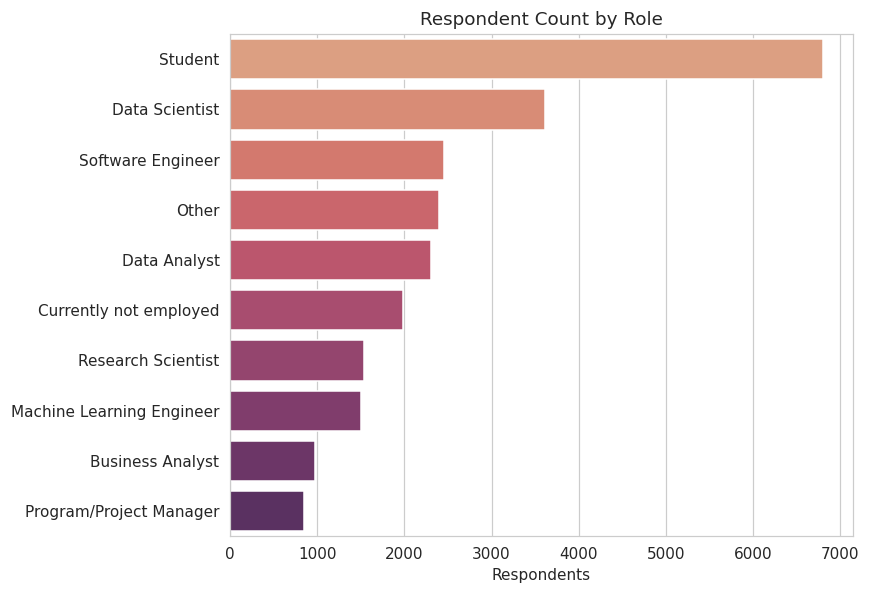

In [16]:
plt.figure(figsize=(8,5.5))
top_roles = sub['Role'].value_counts().head(10)
sns.barplot(x=top_roles.values, y=top_roles.index, hue=top_roles.index, palette='flare', legend=False)
plt.title('Respondent Count by Role')
plt.xlabel('Respondents'); plt.ylabel('')
plt.tight_layout(); plt.show()


### Compensation bracket vs. coding experience

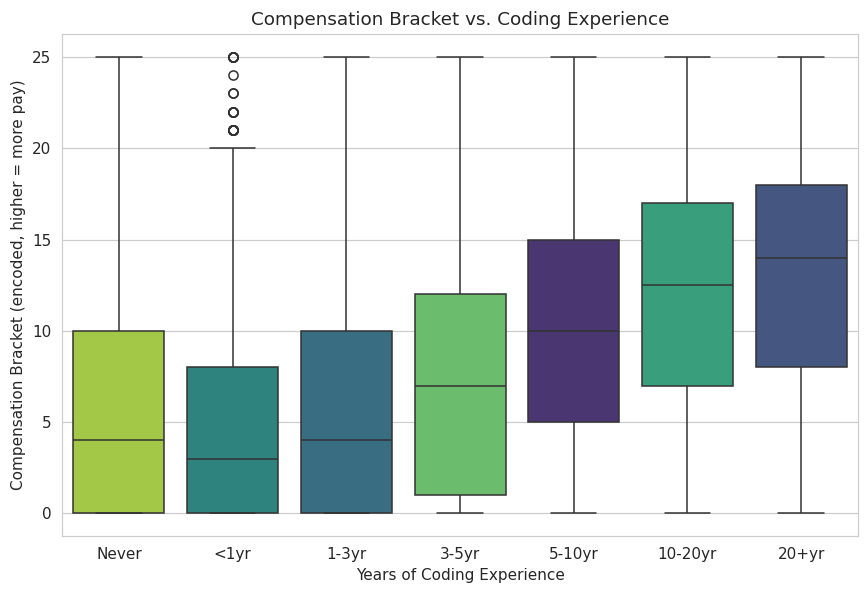

In [17]:
plt.figure(figsize=(8,5.5))
valid = sub[sub['Compensation_Code'].notna()].copy()
exp_labels = {0:'Never',1:'<1yr',2:'1-3yr',3:'3-5yr',4:'5-10yr',5:'10-20yr',6:'20+yr'}
valid['ExpLabel'] = valid['CodingExperience_Code'].map(exp_labels)
order = ['Never','<1yr','1-3yr','3-5yr','5-10yr','10-20yr','20+yr']
sns.boxplot(data=valid, x='ExpLabel', y='Compensation_Code', order=order, hue='ExpLabel', palette='viridis', legend=False)
plt.title('Compensation Bracket vs. Coding Experience')
plt.xlabel('Years of Coding Experience'); plt.ylabel('Compensation Bracket (encoded, higher = more pay)')
plt.tight_layout(); plt.show()


### Age distribution

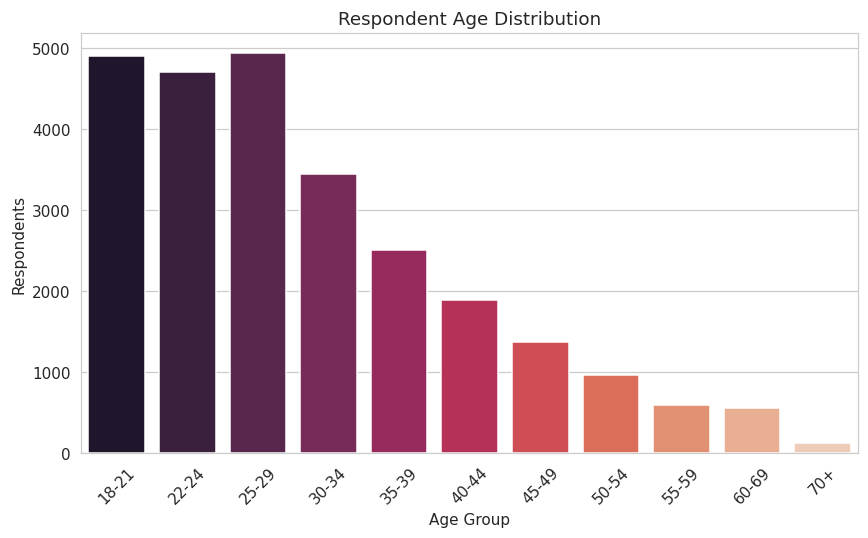

In [18]:
plt.figure(figsize=(8,5))
age_order = ['18-21','22-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-69','70+']
age_counts = sub['Age'].value_counts().reindex(age_order)
sns.barplot(x=age_counts.index, y=age_counts.values, hue=age_counts.index, palette='rocket', legend=False)
plt.title('Respondent Age Distribution')
plt.xlabel('Age Group'); plt.ylabel('Respondents')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()


### Bonus: Top 5 Insights summary dashboard

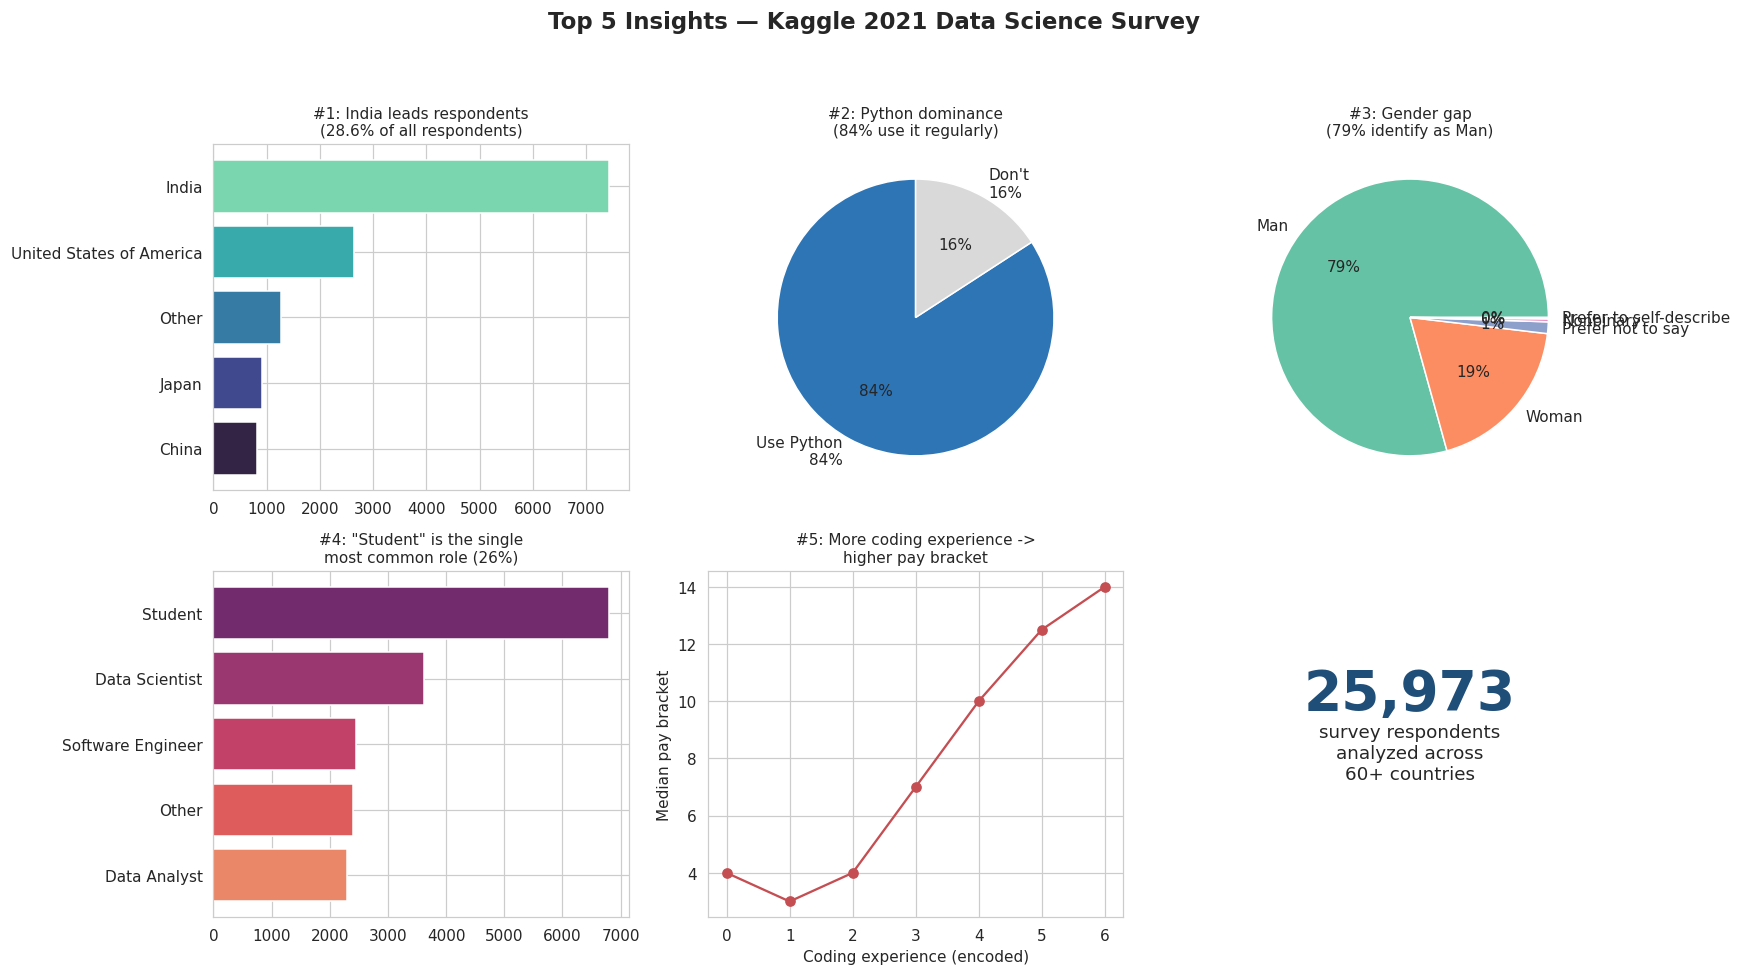

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))
fig.suptitle('Top 5 Insights — Kaggle 2021 Data Science Survey', fontsize=15, fontweight='bold')

ax = axes[0,0]
tc = sub['Country'].value_counts().head(5)
ax.barh(tc.index[::-1], tc.values[::-1], color=sns.color_palette('mako',5))
ax.set_title('#1: India leads respondents\n(28.6% of all respondents)', fontsize=10)

ax = axes[0,1]
py_pct = (sub['Python'].sum()/len(sub))*100
other_pct = 100-py_pct
ax.pie([py_pct, other_pct], labels=[f'Use Python\n{py_pct:.0f}%', f"Don't\n{other_pct:.0f}%"],
       colors=['#2E75B6','#D9D9D9'], autopct='%1.0f%%', startangle=90)
ax.set_title('#2: Python dominance\n(84% use it regularly)', fontsize=10)

ax = axes[0,2]
gc = sub['Gender'].value_counts()
ax.pie(gc.values, labels=gc.index, autopct='%1.0f%%', colors=sns.color_palette('Set2',len(gc)))
ax.set_title('#3: Gender gap\n(79% identify as Man)', fontsize=10)

ax = axes[1,0]
tr = sub['Role'].value_counts().head(5)
ax.barh(tr.index[::-1], tr.values[::-1], color=sns.color_palette('flare',5))
ax.set_title('#4: "Student" is the single\nmost common role (26%)', fontsize=10)

ax = axes[1,1]
valid2 = sub[sub['Compensation_Code'].notna()]
exp_pay = valid2.groupby('CodingExperience_Code')['Compensation_Code'].median()
ax.plot(exp_pay.index, exp_pay.values, marker='o', color='#C44E52')
ax.set_title('#5: More coding experience ->\nhigher pay bracket', fontsize=10)
ax.set_xlabel('Coding experience (encoded)'); ax.set_ylabel('Median pay bracket')

ax = axes[1,2]
ax.axis('off')
ax.text(0.5, 0.6, f"{len(sub):,}", fontsize=36, fontweight='bold', ha='center', color='#1F4E78')
ax.text(0.5, 0.4, "survey respondents\nanalyzed across\n60+ countries", fontsize=12, ha='center')

plt.tight_layout(rect=[0,0,1,0.94])
plt.show()


## 7. Key Insights

1. **India leads respondents** — 7,434 of 25,973 respondents (28.6%) reside in India,
   nearly 3x the United States (2,650, 10.2%), reflecting Kaggle's especially large
   and active community there.
2. **Python dominates** — recommended as the first language to learn by 78% of
   respondents, and used regularly by 84% — by far the standard entry point and daily
   tool for data science. SQL is a distant second in regular use (41%).
3. **The field remains heavily male-skewed** — 79.3% of respondents identify as Man
   vs. 18.8% as Woman, underscoring an ongoing gender gap in data science/ML.
4. **"Student" is the single most common role** — ahead of Data Scientist, Software
   Engineer, or any employed title (26% of all respondents), showing this survey
   captures a large learner population, not just working professionals.
5. **More coding experience predicts higher pay** — median compensation bracket rises
   steadily and almost monotonically from "never coded" through "20+ years",
   confirming the expected experience-to-compensation relationship in the data.
